# Test nblineage Extension

This notebook tests that the nblineage JupyterLab extension is properly installed and enabled.
- Verify that meme metadata is added to the notebook file

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpi7ypz7cw


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251224-150239',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpsj0iye9j')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1766556160.1727061 seconds


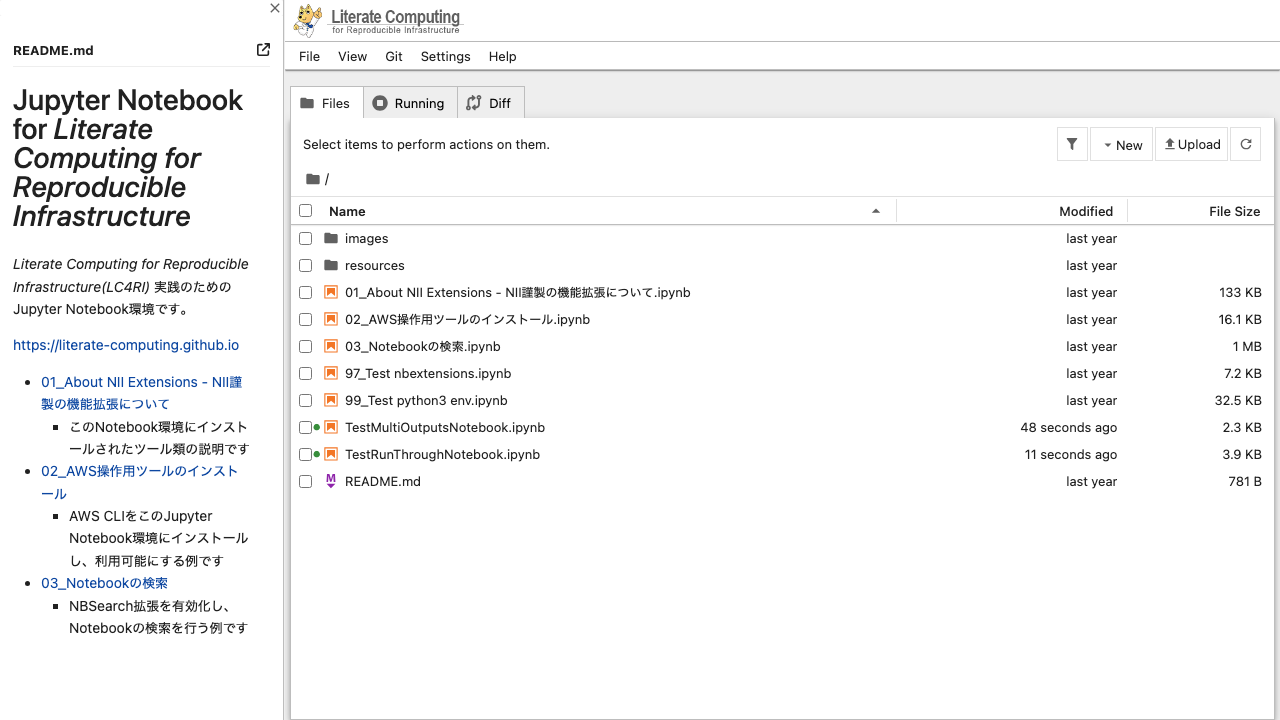

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Remove existing test notebook if it exists

Start epoch: 1766556164.6691542 seconds
No existing test notebook to remove


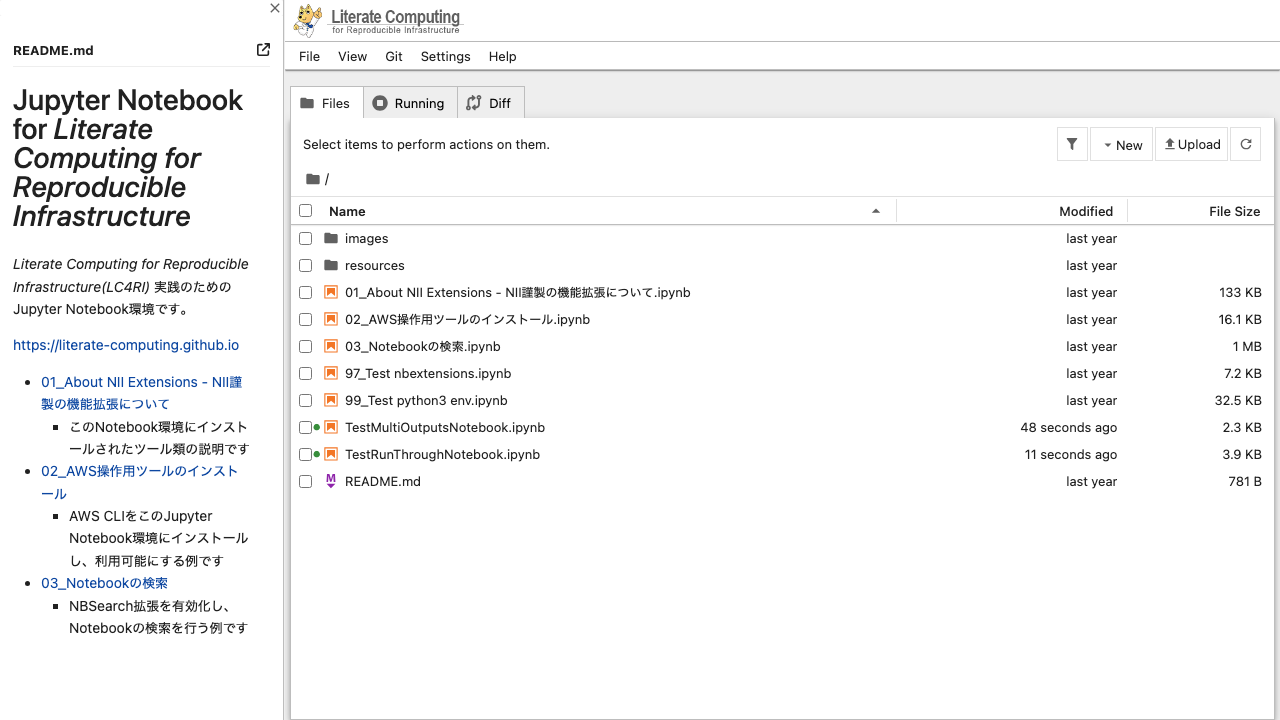

In [6]:
test_filename = "TestNblineageNotebook.ipynb"
async def _step_remove_existing_notebook(page):
    deleted = await delete_file(page, test_filename, timeout=transition_timeout)
    if deleted:
        print("✓ Removed existing test notebook")
    else:
        print("No existing test notebook to remove")

await run_pw(_step_remove_existing_notebook)

## Create a new notebook

Start epoch: 1766556164.817267 seconds


✓ New notebook created


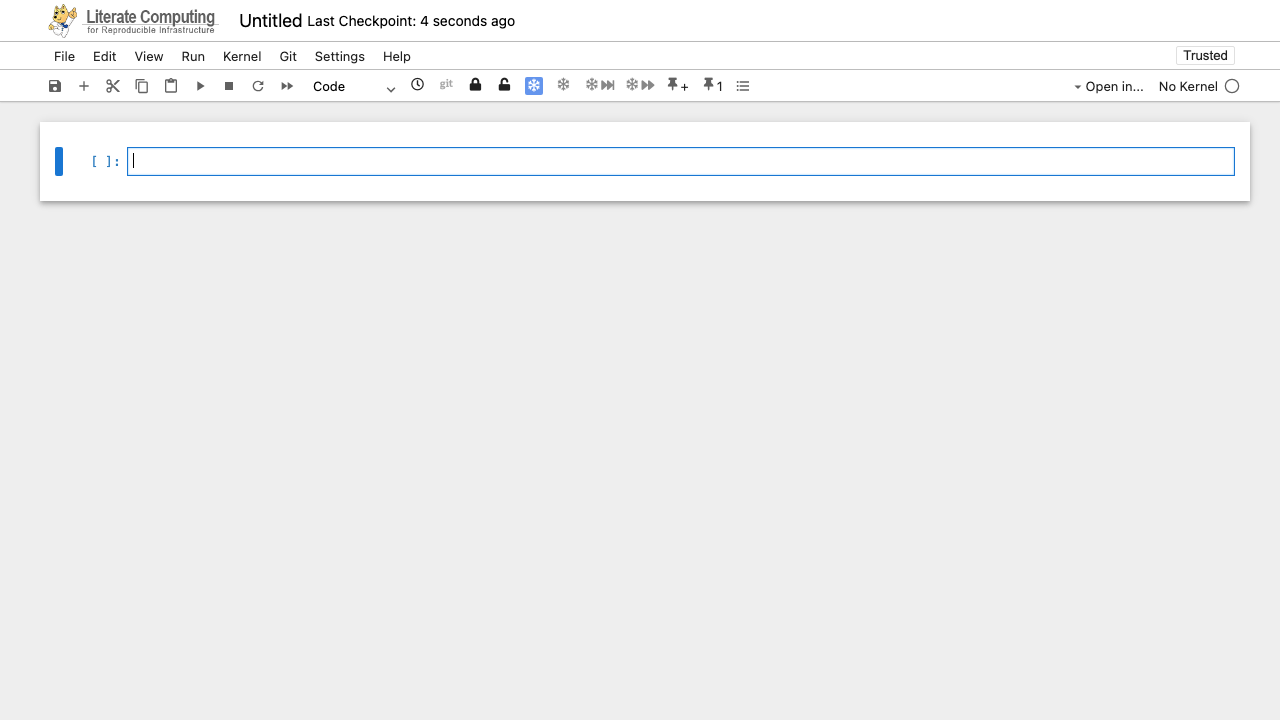

In [7]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Rename and save the notebook

Start epoch: 1766556169.6584089 seconds


✓ Notebook renamed and saved


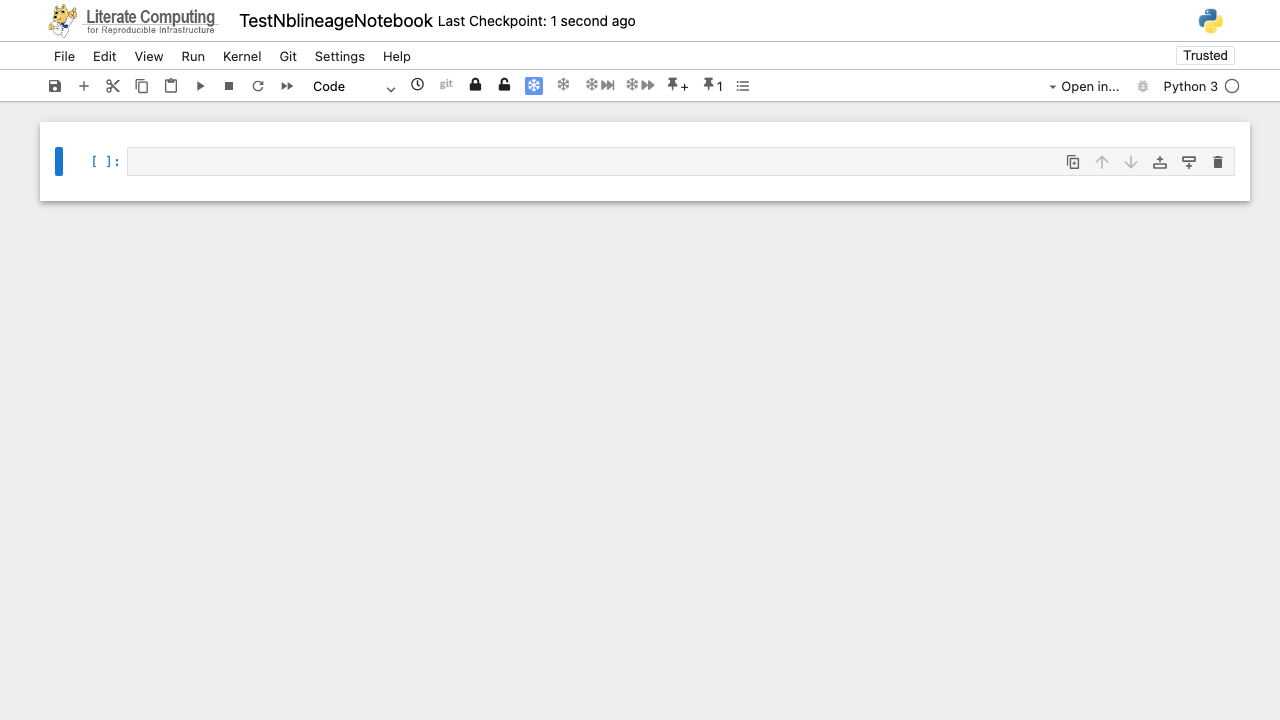

In [8]:
async def _step_rename_and_save(page):
    # Rename the notebook
    await rename_notebook(page, test_filename, timeout=transition_timeout)
    
    # Save the notebook
    await save_notebook(page)
    
    print("✓ Notebook renamed and saved")

await run_pw(_step_rename_and_save)

## Execute a cell to trigger nblineage

Start epoch: 1766556171.605023 seconds


✓ Cell executed


✓ Notebook saved


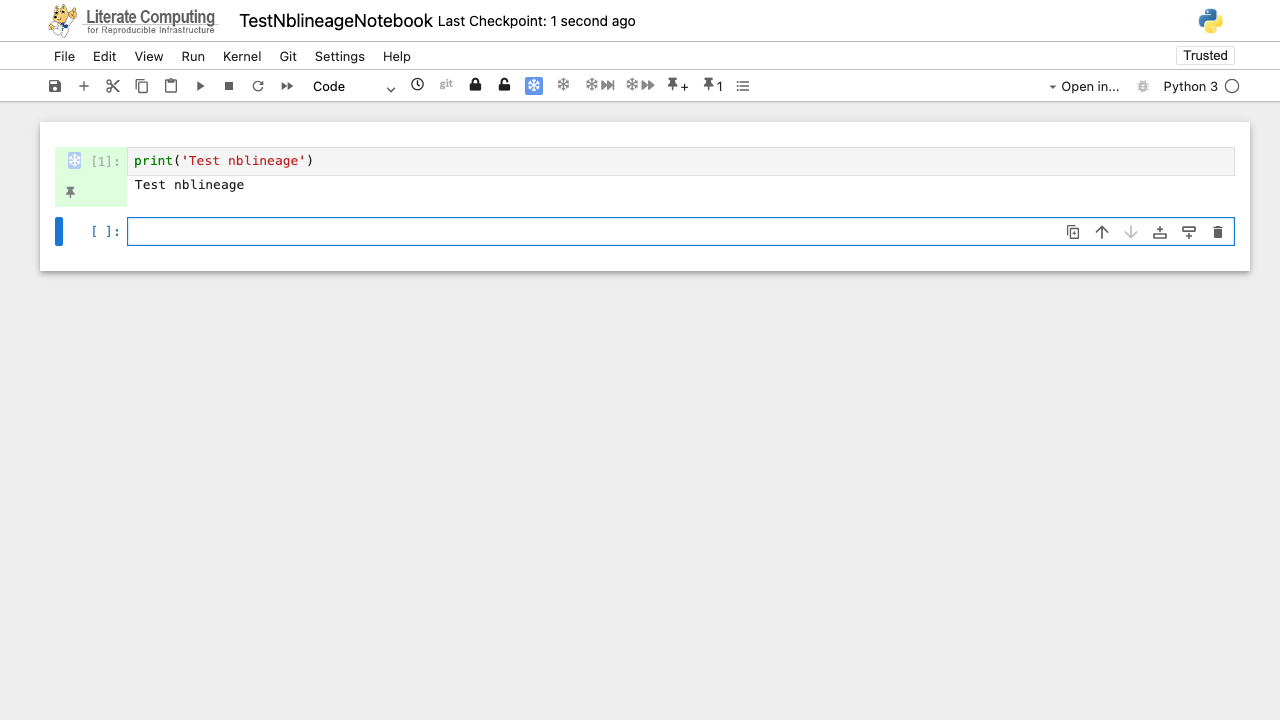

In [9]:
async def _step_execute_cell(page):
    # Create and execute a cell
    await set_cell(page, 0, "code", "print('Test nblineage')", timeout=transition_timeout)
    await run_cell(page, 0, True, timeout=transition_timeout)
    print("✓ Cell executed")
    
    # Save the notebook
    await save_notebook(page)
    print("✓ Notebook saved")

await run_pw(_step_execute_cell)

## Verify meme metadata exists in notebook file

Start epoch: 1766556176.032077 seconds
✓ Loaded notebook from: ../artifacts/jupyter-work/TestNblineageNotebook.ipynb
✓ nblineage meme found in notebook metadata
✓ Notebook 'current' is a valid UUID: 2d283186-e08e-11f0-afcd-0242ac110002
✓ First cell 'current' is a valid UUID: 2d28326c-e08e-11f0-afcd-0242ac110002


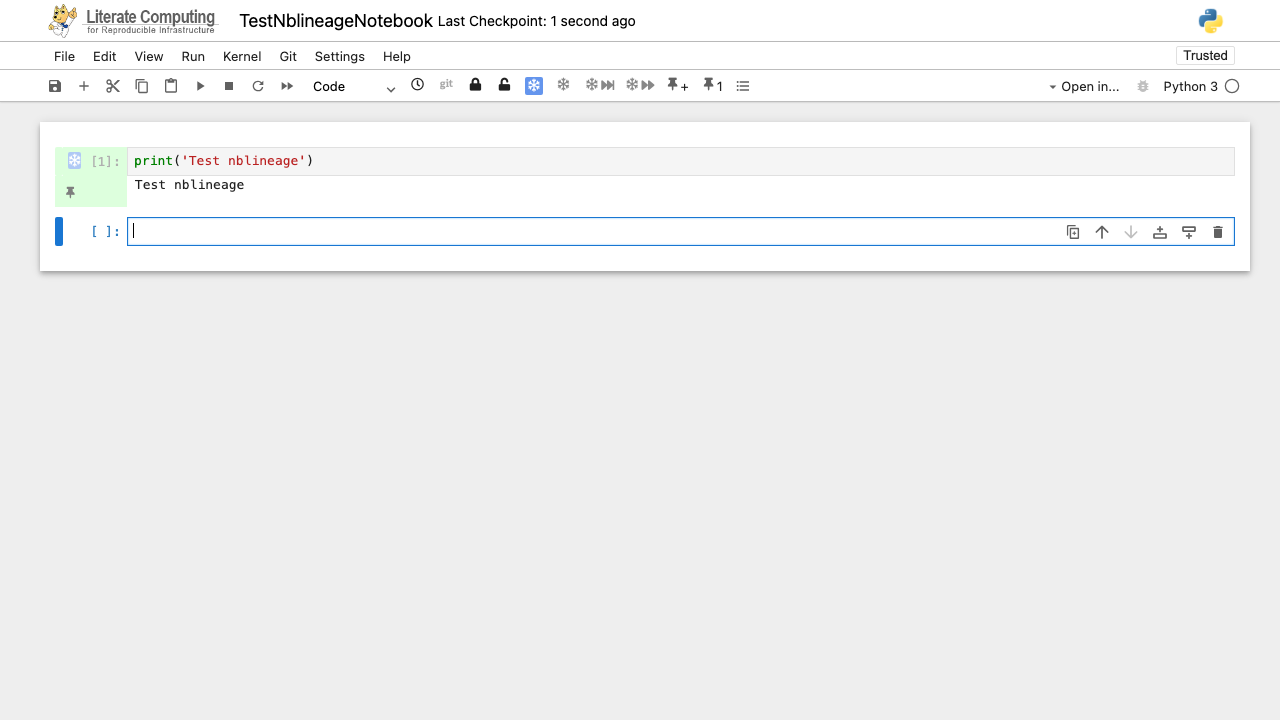

In [10]:
import json
from pathlib import Path

async def _step_verify_meme(page):
    # Read notebook file directly from jupyter_work_dir
    notebook_path = Path(jupyter_work_dir) / test_filename
    assert notebook_path.exists(), f"Notebook file not found: {notebook_path}"

    with open(notebook_path, 'r') as f:
        notebook_data = json.load(f)
    
    print(f"✓ Loaded notebook from: {notebook_path}")
    
    # Check if meme exists in the notebook metadata
    assert 'metadata' in notebook_data, "No metadata in notebook content"
    assert 'lc_notebook_meme' in notebook_data['metadata'], "No lc_notebook_meme in notebook metadata"
    
    print("✓ nblineage meme found in notebook metadata")
    
    # Check if current is a valid UUID
    meme = notebook_data['metadata']['lc_notebook_meme']
    assert 'current' in meme, "No 'current' in lc_notebook_meme"
    
    current = meme['current']
    uuid_pattern = r'^[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}$'
    assert re.match(uuid_pattern, current), f"'current' is not a valid UUID: {current}"
    
    print(f"✓ Notebook 'current' is a valid UUID: {current}")
    
    # Check cell meme
    cells = notebook_data['cells']
    assert len(cells) > 0, "No cells in notebook"
    
    first_cell = cells[0]
    assert 'metadata' in first_cell, "No metadata in first cell"
    assert 'lc_cell_meme' in first_cell['metadata'], "No lc_cell_meme in first cell metadata"
    
    cell_meme = first_cell['metadata']['lc_cell_meme']
    assert 'current' in cell_meme, "No 'current' in lc_cell_meme"
    
    cell_current = cell_meme['current']
    assert re.match(uuid_pattern, cell_current), f"Cell 'current' is not a valid UUID: {cell_current}"
    
    print(f"✓ First cell 'current' is a valid UUID: {cell_current}")

await run_pw(_step_verify_meme)

## Cleanup

In [ ]:
await finish_pw_context()


In [12]:
!rm -rf {work_dir}